In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import IPython
import numpy as np
import eli5
from eli5 import show_prediction
import shap
import lime.lime_tabular
from interpret import set_visualize_provider
from interpret.provider import InlineProvider
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

In [32]:
credito = pd.read_csv('Credit.csv')

In [33]:
credito.shape

(1000, 21)

In [34]:
credito.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,'critical/other existing credit',radio/tv,1169,'no known savings',>=7,4,'male single',none,...,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,'existing paid',radio/tv,5951,<100,1<=X<4,2,'female div/dep/mar',none,...,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,<100,4<=X<7,2,'male single',none,...,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,<0,42,'existing paid',furniture/equipment,7882,<100,4<=X<7,2,'male single',guarantor,...,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,<0,24,'delayed previously','new car',4870,<100,1<=X<4,3,'male single',none,...,'no known property',53,none,'for free',2,skilled,2,none,yes,bad


In [35]:
previsores = credito.iloc[:, :-1].values
classe = credito.iloc[:,-1].values

In [36]:
labelencoder = LabelEncoder()
for i in range(previsores.shape[1]):
  if previsores[:,i].dtype == 'object':
    previsores[:,i] = labelencoder.fit_transform( previsores[:,i])

In [37]:
classe = labelencoder.fit_transform(classe)

In [38]:
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(previsores, classe, test_size=0.3)

In [39]:
modelo = RandomForestClassifier(n_estimators=1000)
modelo.fit(X_treinamento, y_treinamento)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

### Lime

In [40]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_treinamento = imputer.fit_transform(X_treinamento)
X_teste = imputer.transform(X_teste)

In [41]:
np.isnan(X_treinamento).sum()
np.isnan(X_teste).sum()

np.int64(0)

In [42]:
pd.DataFrame(X_treinamento).isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
dtype: int64

In [43]:
print("NaN treino:", np.isnan(X_treinamento).sum())
print("NaN teste:", np.isnan(X_teste).sum())

print("Inf treino:", np.isinf(X_treinamento).sum())
print("Inf teste:", np.isinf(X_teste).sum())

NaN treino: 0
NaN teste: 0
Inf treino: 0
Inf teste: 0


In [44]:
X_treinamento = X_treinamento.astype(float)
X_teste = X_teste.astype(float)

In [45]:
expl = lime.lime_tabular.LimeTabularExplainer(
    X_treinamento, 
    feature_names = credito.columns[:-1].tolist(), 
    class_names=["0","1"]
)

prever = lambda x: modelo.predict_proba(x).astype(float)

exp = expl.explain_instance(X_teste[0], prever, num_features=5)
exp.show_in_notebook(show_all=True)

/home/bruno/Git/learning/ia/.ia_venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:280: RuntimeWarning: invalid value encountered in divide
  out = b1 / a1


ValueError: Input contains NaN.

In [46]:
y_teste[0]

np.int64(0)

### eli5

In [50]:
eli5.show_weights(modelo, feature_names = list(credito)[0:20])

Weight,Feature
0.1314 ± 0.0718,credit_amount
0.1139 ± 0.0674,checking_status
0.1069 ± 0.0580,age
0.1042 ± 0.0562,duration
0.0633 ± 0.0439,purpose
0.0558 ± 0.0438,credit_history
0.0497 ± 0.0371,employment
0.0436 ± 0.0346,residence_since
0.0432 ± 0.0350,installment_commitment
0.0420 ± 0.0342,property_magnitude


In [48]:
previsores[1]

array([1, 29, 3, 7, 770, 3, 0, 1, 0, 2, 1, 2, 3, 1, 1, 0, 3, 0, 0, 1],
      dtype=object)

In [49]:
eli5.show_prediction(modelo, previsores[1], feature_names = list(credito)[0:20], show_feature_values=True)

### Shap

In [51]:
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_teste)

abs_shap_values = np.abs(shap_values)

importancia_geral = np.mean(np.mean(abs_shap_values, axis=2),axis=0)
print(importancia_geral)

[0.10332055 0.04939079 0.02893536 0.01645898 0.02332539 0.0162113
 0.01365266 0.01560689 0.01390631 0.00340532 0.00904619 0.00980586
 0.03063152 0.01769844 0.00946639 0.00494152 0.00444886 0.00716409
 0.00855083 0.00259989]


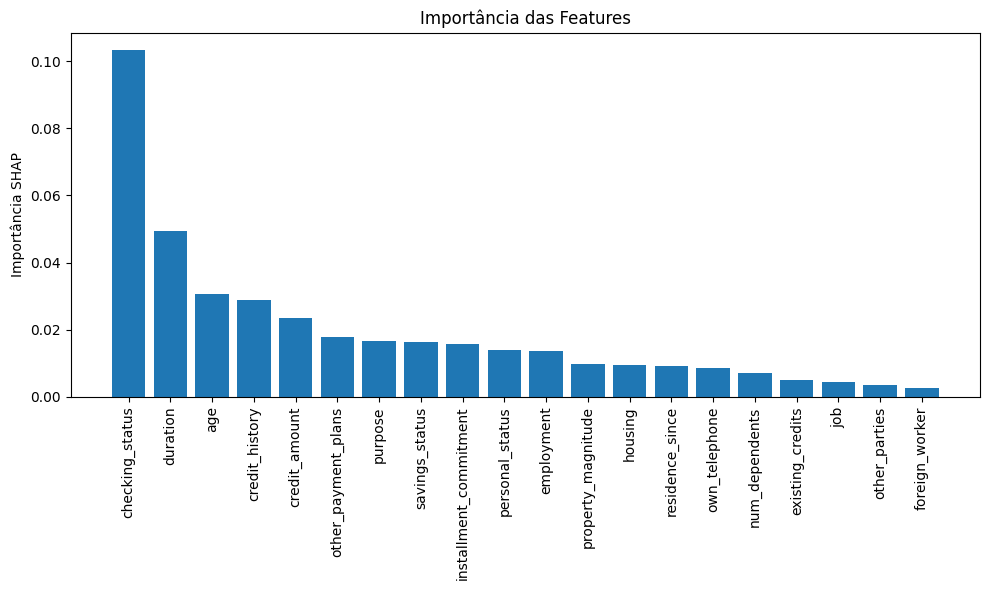

In [52]:
importancia_df = pd.DataFrame({
  'Feature': credito.columns[:-1],
  'Importance':  importancia_geral
}).sort_values(by='Importance', ascending=False)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(importancia_df['Feature'],importancia_df['Importance'] )
plt.xticks(rotation=90)
plt.ylabel("Importância SHAP")
plt.title("Importância das Features")
plt.tight_layout()
plt.show()

### Interpret

In [53]:
set_visualize_provider(InlineProvider())
ebm = ExplainableBoostingClassifier(feature_names=list(credito)[0:20])
ebm.fit(X_treinamento, y_treinamento)
global_explanation = ebm.explain_global()
show(global_explanation)